# Import Packages

In [61]:
# import libraries
from locale import normalize
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline

import joblib
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

from keras.layers import Input, Dropout, Dense, LSTM, TimeDistributed, RepeatVector
from keras.models import Model
from keras import regularizers

# set random seed for reproduciblity
np.random.seed(10)
tf.random.set_seed(10)

# Loading Dataset

테스트용 데이터셋.

데이터셋 전처리 과정은 도메인에 맞게 준비.

In [62]:
## Dataset loading
# def data_load():
#     data_dir= 'data/bearing_data'
#     merged_data= pd.DataFrame()

#     for filename in os.listdir(data_dir):
#         dataset= pd.read_csv(os.path.join(data_dir, filename), sep='\t')
#         dataset_mean_abs= np.array(dataset.abs().mean())
#         dataset_mean_abs= pd.DataFrame(dataset_mean_abs.reshape(1,4))
#         dataset_mean_abs.index= [filename]
#         merged_data= pd.concat([merged_data, dataset_mean_abs], axis=0)

#     merged_data.columns= ['Bearing_1', 'Bearing_2', 'Bearing_3', 'Bearing_4']

#     ## Transform data file index to datetime and sort in chronological order
#     merged_data.index= pd.to_datetime(merged_data.index, format= '%Y.%m.%d.%H.%M.%S')
#     merged_data= merged_data.sort_index()
#     merged_data.to_csv('Averaged_BearingTest_dataset.csv')
#     print("Dataset shape:", merged_data.shape)

#     ## Data split
#     train= merged_data['2004-02-12 10:52:39':'2004-02-15 12:52:39']
#     test= merged_data['2004-02-15 12:52:39':]
#     return train, test


def data_load(file_name, index):
    dataset= pd.read_csv(file_name, index_col=index)
    dataset.columns= ['RX_AVG']
    print("Dataset shape:", dataset.shape)

    return dataset

In [63]:
## loading data
# train, test= data_load()
# print("dataset for training shape : ", train.shape)
# print("datset for testing shape : ", test.shape)

train= data_load('optic_power_data_train.csv', 'Time')
test= data_load('optic_power_data_anomal.csv', 'Time')
print("dataset for training shape : ", train.shape)
print("datset for testing shape : ", test.shape)

Dataset shape: (2592, 1)
Dataset shape: (96, 1)
dataset for training shape :  (2592, 1)
datset for testing shape :  (96, 1)


# Visualize Data

In [64]:
## visaulize dataset
# def data_visualize(data, title):
#     fig, ax= plt.subplots(figsize= (14,6), dpi=80)
#     ax.plot(data['Bearing_1'], label='Bearing 1', color='blue', linewidth=1)
#     ax.plot(data['Bearing_2'], label='Bearing 2', color='red', linewidth=1)
#     ax.plot(data['Bearing_3'], label='Bearing 3', color='green', linewidth=1)
#     ax.plot(data['Bearing_4'], label='Bearing 4', color='black', linewidth=1)
#     plt.legend(loc='lower left')
#     ax.set_title(title, fontsize= 16)
#     plt.show()

def data_visualize(data, title):
    fig, ax= plt.subplots(figsize= (14,6), dpi=80)
    ax.plot(data['RX_AVG'], label='RX_AVG', color='blue', linewidth=1)
    plt.legend(loc='lower left')
    ax.set_title(title, fontsize= 16)
    plt.show()

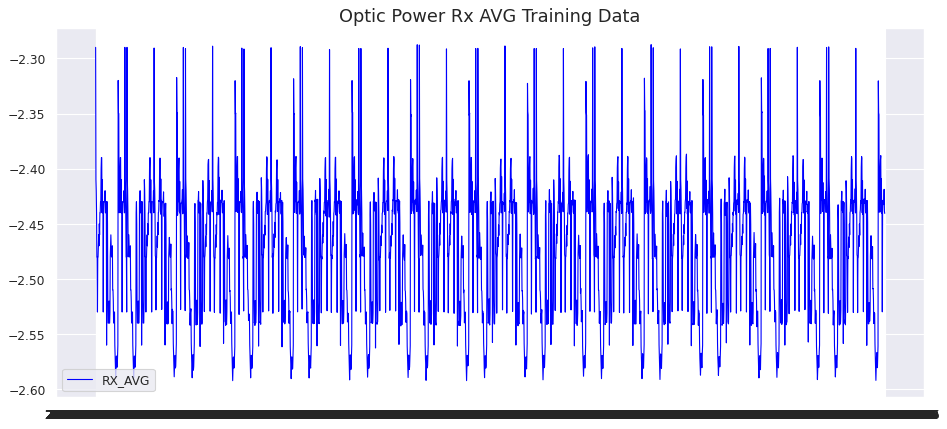

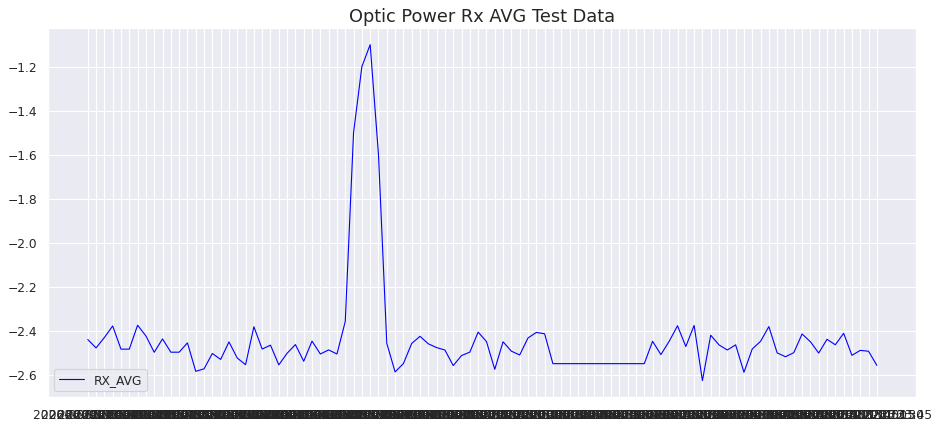

In [82]:
data_visualize(train,'Optic Power Rx AVG Training Data')
data_visualize(test, 'Optic Power Rx AVG Test Data')

# Standardization

In [66]:
## Standardizing data means that data is mapped into normal distribution.
## This helps data to be trained more effectively.

def normalize_data(train, test):
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(train)
    X_test = scaler.transform(test)
    scaler_filename = "scaler_data"
    joblib.dump(scaler, scaler_filename)
    return X_train, X_test

# Reshape

In [67]:
## Reshaping data for training LSTM model
def reshape_data(train, test):
    ## Reshape inputs for LSTM [samples, timesteps, features]
    X_train= train.reshape(train.shape[0], 1, train.shape[1])
    X_test= test.reshape(test.shape[0], 1, test.shape[1])
    print("Training data shape : ", X_train.shape)
    print("Test data shape : ", X_test.shape)
    return X_train, X_test

In [68]:
X_train, X_test= normalize_data(train, test)
X_train, X_test= reshape_data(X_train, X_test)

Training data shape :  (2592, 1, 1)
Test data shape :  (96, 1, 1)


# Modeling

In [69]:
def autoencoder_model(X):
    model= tf.keras.Sequential([
        ## Encoder
        Input(shape=(X.shape[1], X.shape[2])),
        LSTM(64, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(32, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(16, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(4, activation='relu', return_sequences=False),
        ## latent vector
        RepeatVector(X.shape[1]),
        ## Decoder
        LSTM(4, activation='relu', return_sequences=True),
        LSTM(16, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(32, activation='relu', return_sequences=True, kernel_regularizer= regularizers.l2(0.00)),
        LSTM(64, activation='relu', return_sequences=True),
        TimeDistributed(Dense(X.shape[2]))
    ])
    return model

In [70]:
def modelling(X_train, epochs, batch_size):
    model= autoencoder_model(X_train)
    model.compile(optimizer='adam', loss='mae')
    model.summary()

    ## fit the model to the data
    history= model.fit(X_train, X_train, epochs=epochs, batch_size=batch_size, validation_split=0.05)
    return model, history

# Training

In [71]:
epochs= 100
batch_size= 64

model, history= modelling(X_train, epochs, batch_size)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 1, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 1, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 1, 16)          │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 4)              │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 1, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 1, 4)           │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 1, 16)          │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 1, 32)          │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 1, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 1, 1)           │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,441 (255.63 KB)

 Trainable params: 65,441 (255.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 48ms/step - loss: 0.3521 - val_loss: 0.3330
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2503 - val_loss: 0.2062
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1728 - val_loss: 0.1478
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1660 - val_loss: 0.1503
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1599 - val_loss: 0.1131
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0902 - val_loss: 0.0468
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0445 - val_loss: 0.0239
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0259 - val_loss: 0.0213
Epoch 9/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0176 - val_loss: 0.0116
Epoch 10/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0125 - val_loss: 0.0105
Epoch 11/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0104 - val_loss: 0.0082
Epoch 12/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

# Result

In [72]:
def plot_fit(history):
    fig, ax= plt.subplots(figsize=(14, 6), dpi=80)
    ax.plot(history.history['loss'], 'b', label='Train', linewidth=2)
    ax.plot(history.history['val_loss'], 'r', label='Validation', linewidth=2)
    ax.set_title('Model loss', fontsize=16)
    ax.set_ylabel('Loss (mae)')
    ax.set_xlabel('Epoch')
    ax.legend(loc='upper right')
    plt.show()

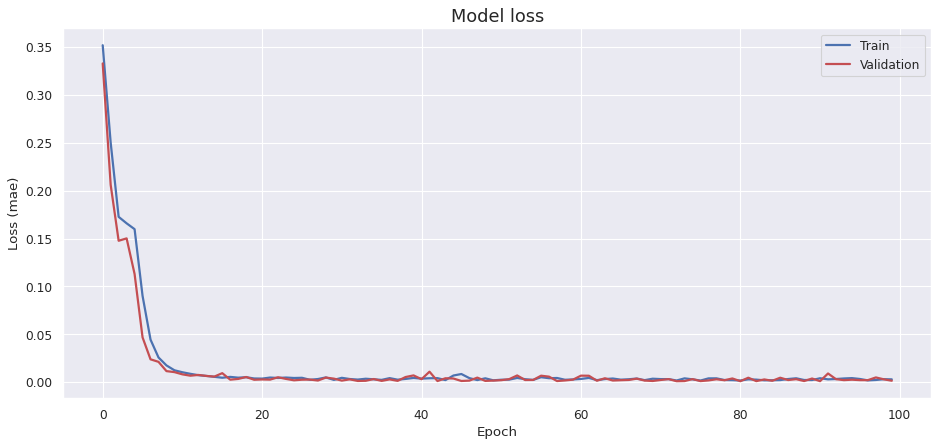

In [73]:
plot_fit(history)

# Anomaly threshold

In [74]:
####################################################################################################
# By plotting the distribution of the calculated loss in the training set,
# we can determine a suitable threshold value for identifying an anomaly.
## plot the loss distribution of the training set
def pred_mae_train(X_train):
    X_pred= model.predict(X_train)
    X_pred= X_pred.reshape(X_pred.shape[0], X_pred.shape[2])
    X_pred= pd.DataFrame(X_pred, columns= train.columns)
    X_pred.index= train.index

    scored= pd.DataFrame(index= train.index)
    Xtrain= X_train.reshape(X_train.shape[0], X_train.shape[2])
    scored['Loss_mae']= np.mean(np.abs(X_pred - Xtrain), axis=1)
    return scored

def pred_mae_test(X_test):
    X_pred= model.predict(X_test)
    X_pred= X_pred.reshape(X_pred.shape[0], X_pred.shape[2])
    X_pred= pd.DataFrame(X_pred, columns= test.columns)
    X_pred.index= test.index

    scored= pd.DataFrame(index= test.index)
    Xtest= X_test.reshape(X_test.shape[0], X_test.shape[2])
    scored['Loss_mae']= np.mean(np.abs(X_pred - Xtest), axis=1)
    return scored

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


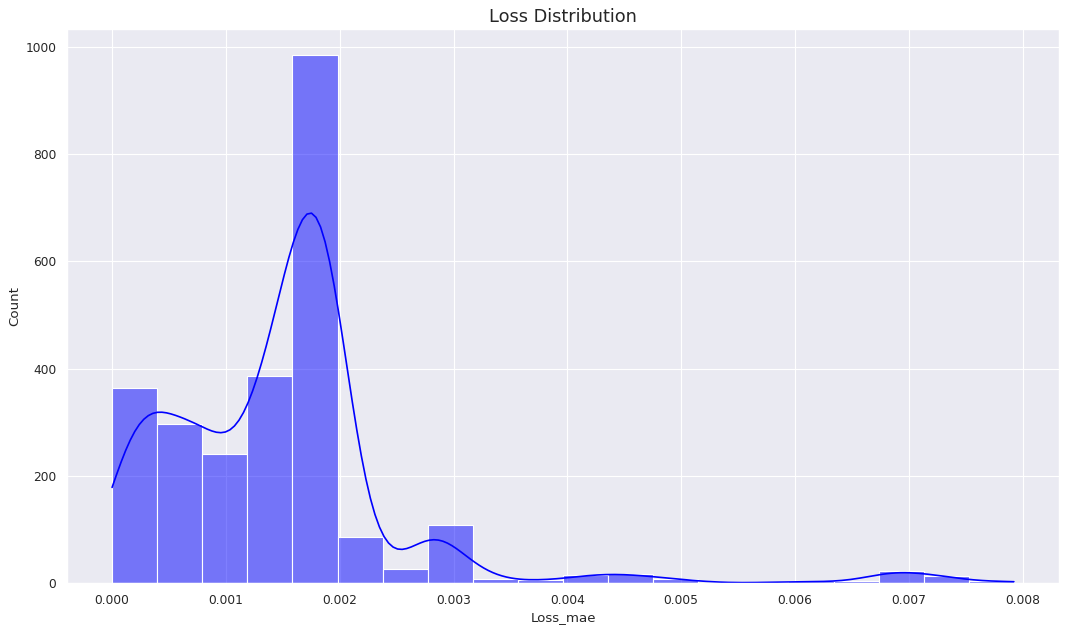

In [75]:
scored= pred_mae_train(X_train)
plt.figure(figsize=(16,9), dpi=80)
plt.title('Loss Distribution', fontsize=16)
sns.histplot(scored['Loss_mae'], bins=20, kde=True, color='blue')
plt.show()

In [76]:
scored['Loss_mae'].describe()

,Loss_mae
count,2.592000e+03
mean,1.498359e-03
std,1.107061e-03
min,3.126001e-07
25%,7.798250e-04
50%,1.590013e-03
75%,1.887546e-03
max,7.923245e-03


# Inference

In [77]:
## Calculate the loss on the test set
# scored_train= pred_mae_train(X_train)
# # scored_train['Threshold']= 0.25
# scored_train['Threshold']= 0.012
# scored_train['Anomaly']= scored_train['Loss_mae'] > scored_train['Threshold']

## calculate the same metrics for the training set
## & merge all data in a single dataframe
scored_test= pred_mae_test(X_test)
# scored_test['Threshold']= 0.25
scored_test['Threshold']= 0.008
scored_test['Anomaly']= scored_test['Loss_mae'] > scored_test['Threshold']
# scored= pd.concat([scored_train, scored_test])
scored= scored_test

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


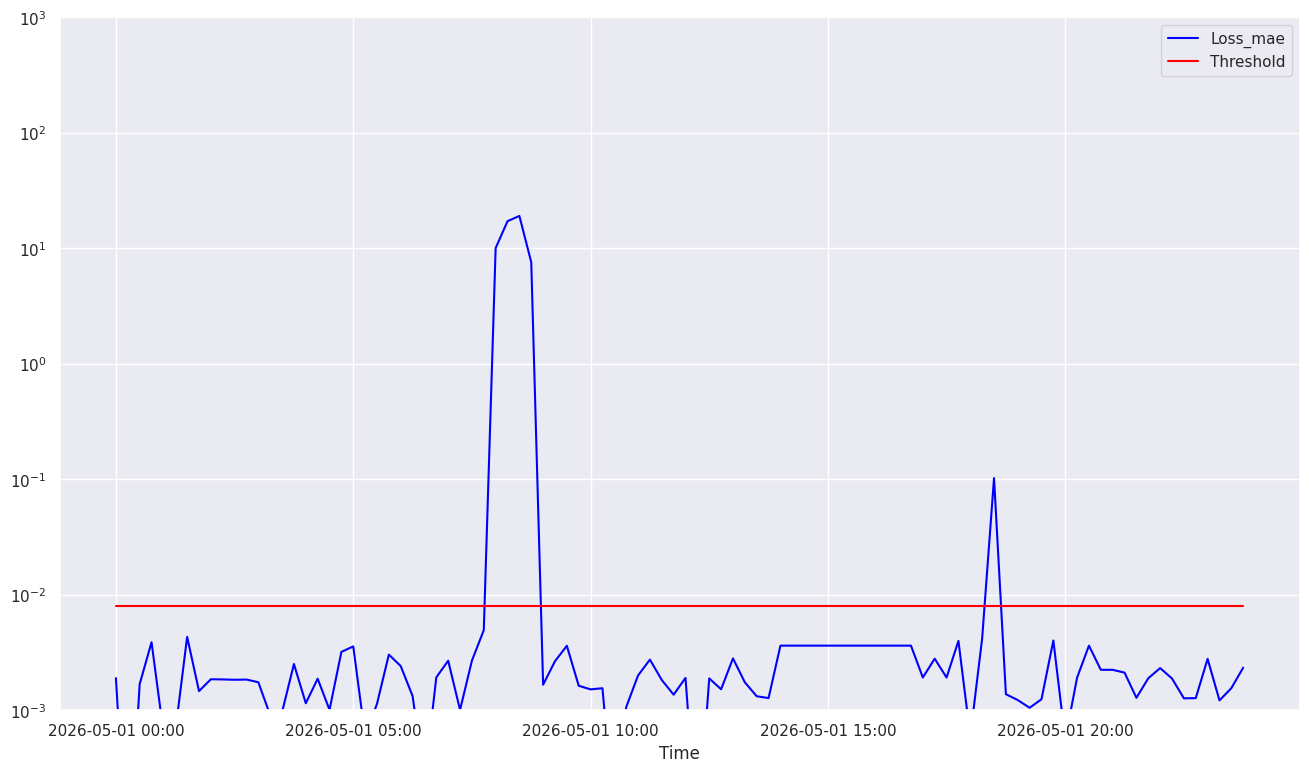

In [79]:
## plot bearing failure timeplot
scored.plot(logy=True, figsize= (16,9), ylim= [1e-3, 1e3], color=['blue', 'red'])
plt.show()

# Anomaly Detection

In [80]:
def vis_result(scored):
    anomaly_df= scored[scored.Anomaly == True]
    plt.plot(scored.index, scored.Loss_mae, label='loss_mae')
    plt.scatter(anomaly_df.index, anomaly_df.Loss_mae, label='anomaly_mae', color='red')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

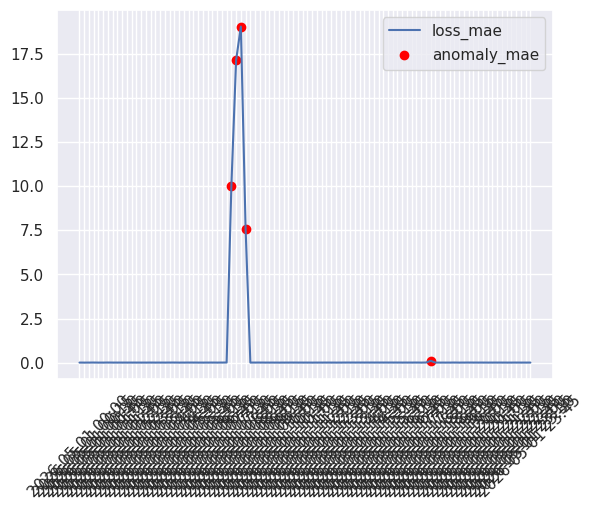

In [81]:
vis_result(scored)